# Diabetes Risk & Population Health Analytics
## 04 - Patient Segmentation & Clustering

This notebook applies clustering techniques to segment individuals into population health risk groups based on clinical and behavioral indicators.

In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

## Load Cleaned Dataset

In [3]:
df = pd.read_csv(
    "/drive/diabetes-risk-analytics-project/data/cleaned_diabetes_data.csv"
)

## Select Features for Clustering

In [4]:
features = [
    "BMI",
    "Age",
    "HighBP",
    "HighChol",
    "PhysActivity",
    "Smoker",
    "GenHlth"
]

X = df[features]

## Feature Standardization

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Elbow Method for Optimal Clusters

In [6]:
inertia = []

K = range(1,11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


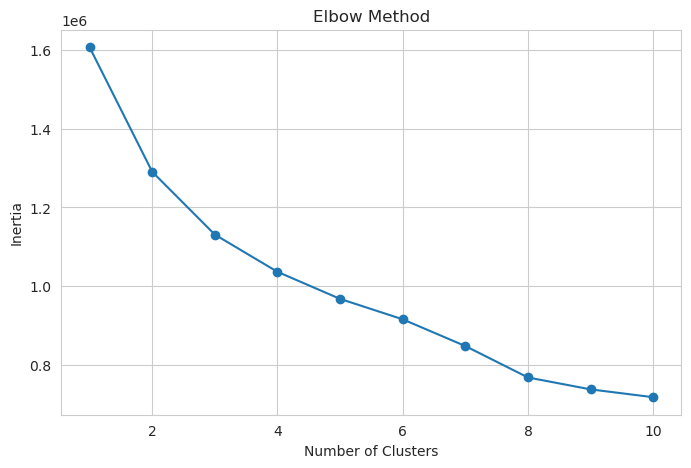

In [7]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

### Interpretation

The elbow curve suggests an optimal cluster range where adding additional clusters yields diminishing returns in reducing inertia.

## Build K-Means Clustering Model

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

## Cluster Distribution

<ipython-input-9-f8bc4db896e4>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


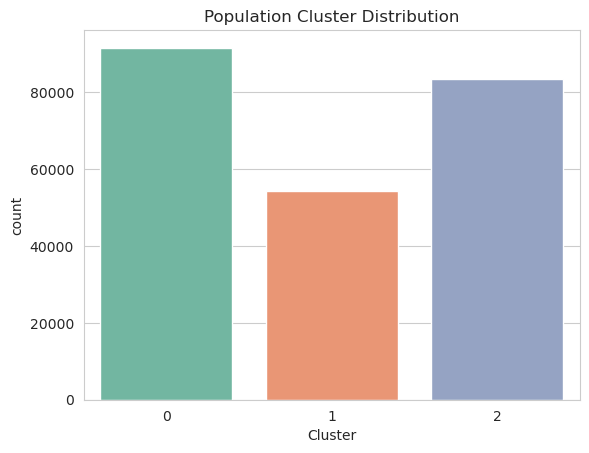

In [9]:
sns.countplot(
    data=df,
    x="Cluster",
    palette="Set2"
)

plt.title("Population Cluster Distribution")

plt.show()

## Cluster Characteristics

In [10]:
cluster_summary = df.groupby("Cluster")[features].mean()

cluster_summary

,BMI,Age,HighBP,HighChol,PhysActivity,Smoker,GenHlth
Cluster,,,,,,,
0,26.740889,6.226160,0.050628,0.162627,0.925177,0.347472,2.046402
1,30.682527,8.995681,0.608042,0.551751,0.000129,0.554343,3.177307
2,29.522942,9.531185,0.797137,0.676015,1.000000,0.537918,2.836109


### Interpretation

The clustering analysis identified distinct population health profiles:

- One cluster demonstrated healthier behavioral patterns and lower clinical risk indicators.
- Another cluster showed elevated BMI, blood pressure, and poorer general health status.
- A third segment exhibited mixed behavioral and chronic disease characteristics.

These findings support population-level risk stratification and targeted preventive healthcare interventions.

## Export Featured Dataset

In [11]:
df.to_csv(
    "/drive/diabetes-risk-analytics-project/data/featured_diabetes_data.csv",
    index=False
)

## Cluster Profile Analysis

## Clustering Summary

K-Means clustering successfully segmented the population into distinct health risk groups based on behavioral and clinical indicators.

The analysis highlighted meaningful differences in:
- BMI
- Blood pressure
- Cholesterol
- Physical activity
- General health status

This segmentation approach can support population health management, preventive care planning, and healthcare resource prioritization.